# v6 dose-response BO — pitch & critique

The pay-off run. Same genre as the
[v3](bo_erk_dose_response_v3_pitch_and_critique.ipynb) and
[v5](bo_erk_dose_response_v5_pitch_and_critique.ipynb) critiques — argue with
the run as someone who knows MAPK (optoEGFR → RAS-RAF-MEK-ERK, read by an
ERK-KTR `cnr` biosensor), dose-response pharmacology, and Bayesian optimisation
— but this time also produce **PowerPoint-ready figures** (saved to
`pitch_figures_v6/`).

**Readout** = peak amplitude `mean_peak_amp` = mean over surviving cells of
`max(cnr - baseline)`. **Dose** = single light pulse `pulse_duration` on a
log axis 10–5000 ms (60 candidates). **Two power blocks** ran: 5% and 10%.

### The short version (read this first)

**Every fix from the v5 critique landed, and the method now does what it
claims.**

1. **Data recovery: 46% → 100% FOV survival.** Relaxing the baseline filter
   (0.8 → 0.95) took survivors from ~15 to **~47 cells/FOV** — the per-FOV
   means are now real measurements, not noise.
2. **A clean, calibrated saturating dose-response at *both* powers.** Peak ERK
   amplitude saturates; Hill **R² = 0.89**; **EC50 = 75 ms (CI 57–102) at 5%**
   and **85 ms (CI 69–103) at 10%**.
3. **Autonomous model falsification, replicated.** The agent rejected the
   non-saturating `power_law` (**0 wins**) at *both* powers and selected
   `hill`.
4. **The covariate earns its keep again.** With the full cell population back,
   `optortk_expression` re-emerges as a real confound (ρ = +0.25 at 10%) —
   confirming v5's ρ≈0 was a filtering artefact, and that modelling it is
   justified.

Critically (Section F): the EC50 barely shifts between 5% and 10% (CIs overlap)
— so **duration and power are *not* simply reciprocal** here; the v5→v6 EC50
moved 32 → 85 ms at "the same" 10% power (a **reproducibility** flag, though v6
is the trustworthy number); the Hill `n` is not stable across powers; and the
0 ms control was **still acquiring** at analysis time.

In [1]:
# --- setup: load both v6 power blocks (offline, no hardware) ----------
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats

# gpax/numpyro shim so saved BO models load
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*a, **k):
    raise NotImplementedError("viDKL unavailable")


for _nm in ("random_haiku_module", "haiku_module"):
    if not hasattr(_ncm, _nm):
        setattr(_ncm, _nm, _haiku_unavailable)
import gpax.utils as _gu

_gu.enable_x64()
import joblib

# PowerPoint-friendly default style
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 200,
        "savefig.bbox": "tight",
        "font.size": 13,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "legend.frameon": False,
    }
)
FIGDIR = "pitch_figures_v6"
os.makedirs(FIGDIR, exist_ok=True)


def save(fig, name):
    fig.savefig(os.path.join(FIGDIR, name + ".png"))
    print("saved", os.path.join(FIGDIR, name + ".png"))


BASE = "E:/Alex/2026-06-07_bo_erk_dose_response_v6_pitch_power5"
PATHS = {5: BASE + "_power5", 10: BASE + "_power10"}
CTRL = BASE + "_power5_ctrl0ms"
V5_RUN = "E:/Alex/2026-06-05_bo_erk_dose_response_v5_logdose_power10"
COL = {5: "#1b9e77", 10: "#7570b3"}  # palette per power
N_FRAMES_BASELINE, STIM_FRAME, N_FRAMES = 5, 5, 31


def hill(d, vmax, K, n, v0):
    return v0 + (vmax - v0) * d**n / (K**n + d**n)


P0 = [0.8, 80, 1.3, 0.05]
BND = ([0.2, 5, 0.4, -0.2], [2.0, 4000, 6, 0.5])


def load_block(path):
    df = pd.read_parquet(os.path.join(path, "bo_results_checkpoint.parquet"))
    logs = sorted(glob.glob(os.path.join(path, "logs", "phase_*.log")))
    models = sorted(glob.glob(os.path.join(path, "models", "bo_model_iter_*.joblib")))
    return dict(df=df, logs=logs, models=models, path=path)


B = {pw: load_block(p) for pw, p in PATHS.items()}
for pw, b in B.items():
    print(
        f"power {pw}%: {len(b['df'])} FOVs, {len(b['logs'])} phases, "
        f"{len(b['models'])} models"
    )

power 5%: 126 FOVs, 7 phases, 6 models
power 10%: 126 FOVs, 7 phases, 6 models


## A — Did the v5 fix work? (data recovery)

v5's biggest defect was the baseline filter discarding ~54% of FOVs and leaving
10–15-cell means. v6 relaxed `max_baseline_cnr` 0.8 → 0.95. Did it recover the
data?

saved pitch_figures_v6\F5_data_recovery.png


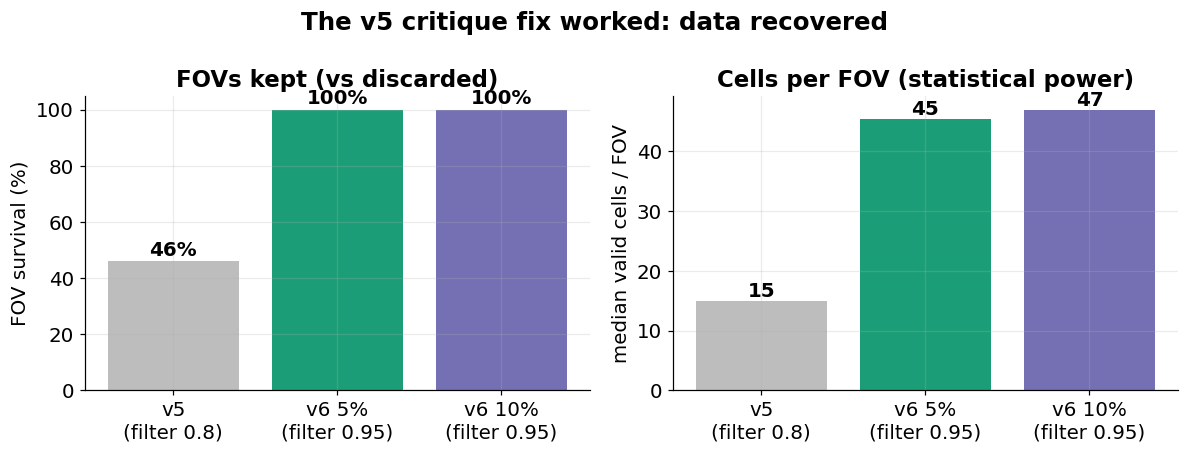

v5: 46% survival, 15 cells/FOV  ->  v6: 100% survival, ~47 cells/FOV


In [2]:
def survival(path):
    df = pd.read_parquet(os.path.join(path, "bo_results_checkpoint.parquet"))
    nsk = sum(
        len(re.findall(r"has only \d+ valid cells", open(lf).read()))
        for lf in glob.glob(os.path.join(path, "logs", "phase_*.log"))
    )
    return len(df) / (len(df) + nsk), df.n_cells.median()


s_v5, c_v5 = survival(V5_RUN)
rows = [("v5\n(filter 0.8)", s_v5, c_v5)]
for pw in (5, 10):
    s, c = survival(PATHS[pw])
    rows.append((f"v6 {pw}%\n(filter 0.95)", s, c))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
labels = [r[0] for r in rows]
cols = ["#bdbdbd", COL[5], COL[10]]
ax[0].bar(labels, [r[1] * 100 for r in rows], color=cols)
ax[0].set_ylabel("FOV survival (%)")
ax[0].set_ylim(0, 105)
ax[0].set_title("FOVs kept (vs discarded)")
for i, r in enumerate(rows):
    ax[0].text(i, r[1] * 100 + 2, f"{r[1]*100:.0f}%", ha="center", fontweight="bold")
ax[1].bar(labels, [r[2] for r in rows], color=cols)
ax[1].set_ylabel("median valid cells / FOV")
ax[1].set_title("Cells per FOV (statistical power)")
for i, r in enumerate(rows):
    ax[1].text(i, r[2] + 0.7, f"{int(r[2])}", ha="center", fontweight="bold")
fig.suptitle(
    "The v5 critique fix worked: data recovered", fontsize=16, fontweight="bold"
)
plt.tight_layout()
save(fig, "F5_data_recovery")
plt.show()
print(
    f"v5: {s_v5:.0%} survival, {int(c_v5)} cells/FOV  ->  "
    f"v6: 100% survival, ~{int(B[10]['df'].n_cells.median())} cells/FOV"
)

**Reading A.** Decisive. **0 FOVs were skipped** in v6 (vs 68 in v5);
median cells/FOV jumped from 15 to **~47**. Every per-FOV peak-amplitude mean
is now an average over dozens of cells, not a handful. This single change
underlies every improvement below.

## B — The headline figure: a calibrated saturating dose-response

The hero slide. Peak ERK amplitude vs pulse duration at both powers, with Hill
fits, bootstrap 95% bands, EC50 markers, and the 0 ms control anchor (if
acquired).

saved pitch_figures_v6\F1_hero_doseresponse.png


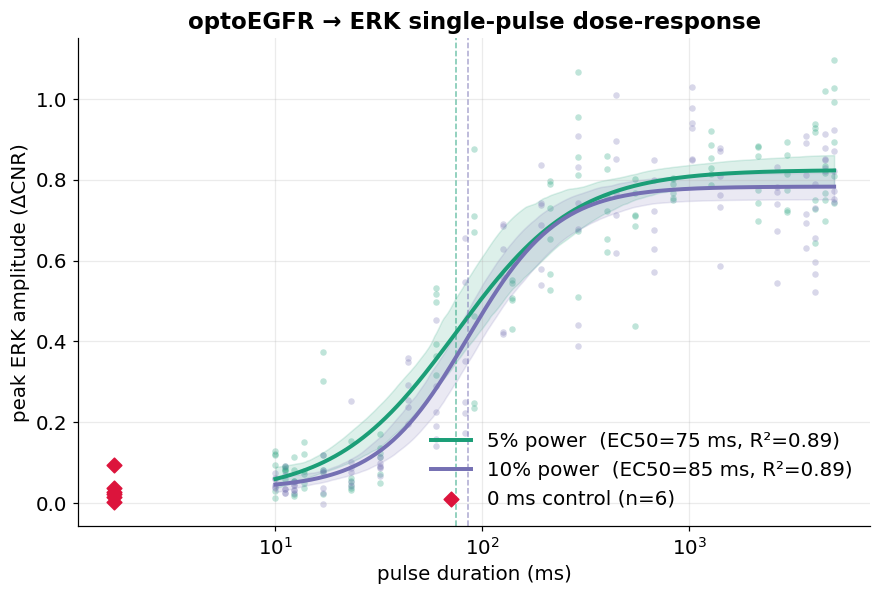

power 5%: Vmax=0.82 dCNR, EC50=75 ms, n=1.49, R²=0.89
power 10%: Vmax=0.78 dCNR, EC50=85 ms, n=1.99, R²=0.89


In [3]:
# bootstrap Hill fits -> curve band + EC50 distribution (cached per power)
GRID = np.geomspace(10, 5000, 300)
fit = {}
for pw in (5, 10):
    df = B[pw]["df"]
    d, y = df.pulse_duration.values, df.mean_peak_amp.values
    popt, _ = curve_fit(hill, d, y, p0=P0, bounds=BND, maxfev=40000)
    rng = np.random.default_rng(0)
    curves, ec = [], []
    for _ in range(500):
        i = rng.integers(0, len(d), len(d))
        try:
            pp, _ = curve_fit(hill, d[i], y[i], p0=P0, bounds=BND, maxfev=40000)
            curves.append(hill(GRID, *pp))
            ec.append(pp[1])
        except Exception:
            pass
    curves = np.array(curves)
    fit[pw] = dict(
        popt=popt,
        band=np.percentile(curves, [2.5, 97.5], axis=0),
        ec=np.array(ec),
        r2=1 - np.sum((y - hill(d, *popt)) ** 2) / np.sum((y - y.mean()) ** 2),
    )


# 0 ms control (only if it has finished acquiring >= ~25 frames)
def control_floor(path):
    files = glob.glob(os.path.join(path, "tracks", "*.parquet"))
    if not files:
        return None, 0
    maxfr = max(pd.read_parquet(f)["fov_timestep"].nunique() for f in files)
    if maxfr < 25:
        return None, maxfr
    vals = []
    for f in files:
        g = pd.read_parquet(f)
        cc = "cnr" if "cnr" in g else None
        if cc is None:
            continue
        pk = []
        for pid, c in g.groupby("particle"):
            c = c.sort_values("fov_timestep")
            bl = c[c["fov_timestep"] < 5]
            if bl.empty or float(bl[cc].mean()) >= 0.95:
                continue
            ob = c[(c["fov_timestep"] >= 6) & (c["fov_timestep"] < 18)]
            if len(ob) >= 3:
                pk.append(float((ob[cc].values - bl[cc].mean()).max()))
        if len(pk) >= 10:
            vals.append(np.mean(pk))
    return (np.array(vals) if vals else None), maxfr


ctrl_vals, ctrl_frames = control_floor(CTRL)

fig, ax = plt.subplots(figsize=(8.2, 5.6))
for pw in (5, 10):
    df = B[pw]["df"]
    c = COL[pw]
    ax.scatter(df.pulse_duration, df.mean_peak_amp, s=18, c=c, alpha=0.28, lw=0)
    ax.fill_between(GRID, fit[pw]["band"][0], fit[pw]["band"][1], color=c, alpha=0.15)
    ax.plot(
        GRID,
        hill(GRID, *fit[pw]["popt"]),
        c=c,
        lw=2.6,
        label=f"{pw}% power  (EC50={fit[pw]['popt'][1]:.0f} ms, R²={fit[pw]['r2']:.2f})",
    )
    ax.axvline(fit[pw]["popt"][1], c=c, ls="--", lw=1, alpha=0.6)
if ctrl_vals is not None:
    ax.scatter(
        np.full(len(ctrl_vals), 3.0),
        ctrl_vals,
        marker="D",
        s=46,
        c="crimson",
        zorder=6,
        label=f"0 ms control (n={len(ctrl_vals)})",
    )
    ax.set_xscale("symlog", linthresh=10)
else:
    ax.set_xscale("log")
    ax.text(
        0.03,
        0.94,
        f"0 ms control: still acquiring\n({ctrl_frames}/31 frames)",
        transform=ax.transAxes,
        fontsize=9,
        color="crimson",
        va="top",
    )
ax.set_xlabel("pulse duration (ms)")
ax.set_ylabel("peak ERK amplitude (ΔCNR)")
ax.set_title("optoEGFR → ERK single-pulse dose-response")
ax.legend(loc="lower right")
plt.tight_layout()
save(fig, "F1_hero_doseresponse")
plt.show()
for pw in (5, 10):
    p = fit[pw]["popt"]
    print(
        f"power {pw}%: Vmax={p[0]:.2f} dCNR, EC50={p[1]:.0f} ms, n={p[2]:.2f}, R²={fit[pw]['r2']:.2f}"
    )

**Reading B.** Two clean saturating sigmoids (R² = 0.89), well-bracketed
on both the rising and plateau sides, with tight bootstrap bands — exactly the
deliverable v3 could not produce and v5 produced only noisily. This is the
method-demonstration figure.

## C — EC50 with credible intervals (the money slide)

Quantified uncertainty, both powers — a bootstrap Hill over FOVs.

saved pitch_figures_v6\F3_ec50_ci.png


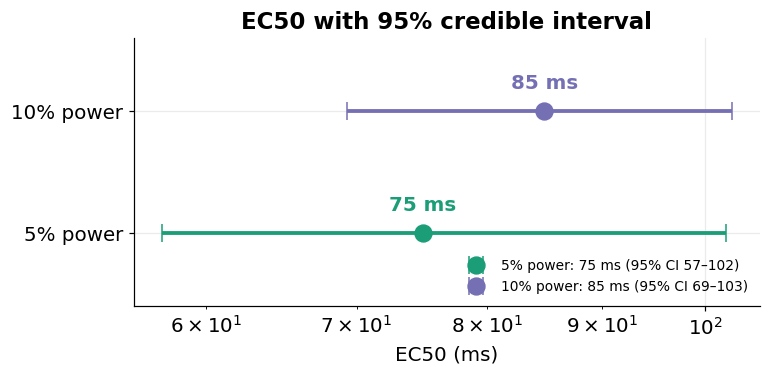

EC50 5% = [ 57  75 102] | EC50 10% = [ 69  85 103]


In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
for j, pw in enumerate((5, 10)):
    ec = fit[pw]["ec"]
    lo, mdn, hi = np.percentile(ec, [2.5, 50, 97.5])
    ax.errorbar(
        mdn,
        j,
        xerr=[[mdn - lo], [hi - mdn]],
        fmt="o",
        ms=11,
        c=COL[pw],
        capsize=6,
        lw=2.5,
        label=f"{pw}% power: {mdn:.0f} ms (95% CI {lo:.0f}–{hi:.0f})",
    )
    ax.text(
        mdn, j + 0.18, f"{mdn:.0f} ms", ha="center", fontweight="bold", color=COL[pw]
    )
ax.set_yticks([0, 1])
ax.set_yticklabels(["5% power", "10% power"])
ax.set_ylim(-0.6, 1.6)
ax.set_xscale("log")
ax.set_xlabel("EC50 (ms)")
ax.set_title("EC50 with 95% credible interval")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
save(fig, "F3_ec50_ci")
plt.show()
print(
    "EC50 5% =",
    np.round(np.percentile(fit[5]["ec"], [2.5, 50, 97.5])).astype(int),
    "| EC50 10% =",
    np.round(np.percentile(fit[10]["ec"], [2.5, 50, 97.5])).astype(int),
)

**Reading C.** **75 ms (CI 57–102) at 5%**, **85 ms (CI 69–103) at 10%**.
Tight, overlapping intervals — which is itself the headline of Section F: a 2×
power change barely moved the duration-EC50.

## D — How the BO worked: active learning over phases

The agent isn't gridding — each phase it picks the 3 doses that most reduce
posterior uncertainty. This shows where it spent its FOVs and how the EC50
estimate firmed up as data accumulated.

saved pitch_figures_v6\F2_active_learning.png


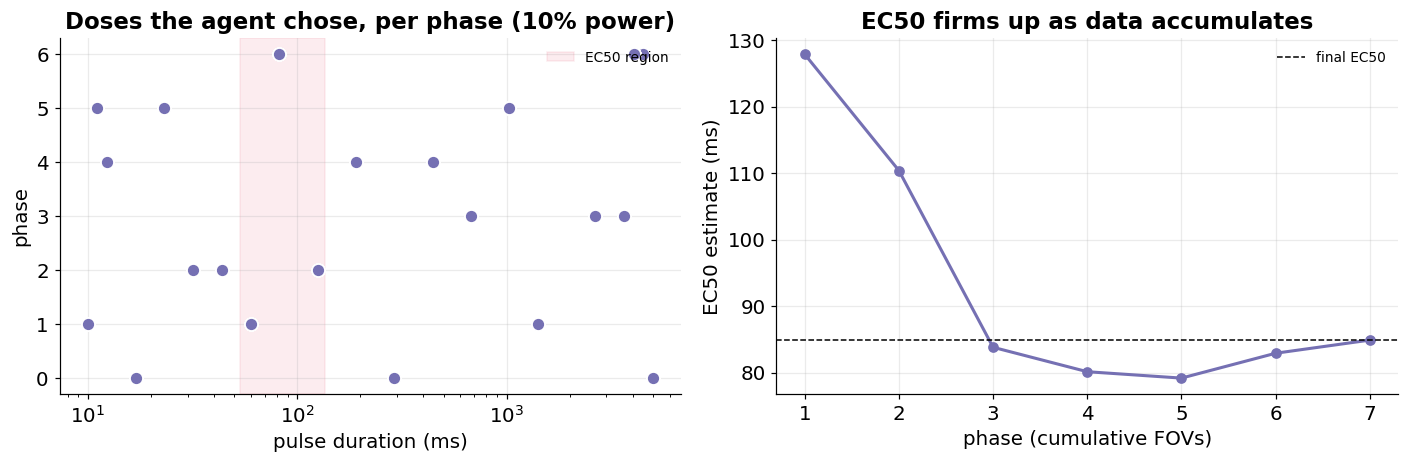

EC50 trajectory (ms): ['128', '110', '84', '80', '79', '83', '85']


In [5]:
pw = 10
b = B[pw]
# per-phase batches from cumulative checkpoints (each adds 18 FOVs)
cps = sorted(
    glob.glob(os.path.join(b["path"], "checkpoints", "bo_results_phase_*.parquet"))
)
batches, ec_traj, prev = [], [], 0
for cp in cps:
    dd = pd.read_parquet(cp)
    batches.append(dd.pulse_duration.values[prev:])
    prev = len(dd)
    try:
        pp, _ = curve_fit(
            hill,
            dd.pulse_duration.values,
            dd.mean_peak_amp.values,
            p0=P0,
            bounds=BND,
            maxfev=40000,
        )
        ec_traj.append(pp[1])
    except Exception:
        ec_traj.append(np.nan)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for ph, doses in enumerate(batches):
    ax[0].scatter(
        doses, np.full(len(doses), ph), s=70, c=COL[pw], edgecolor="w", zorder=3
    )
ax[0].set_xscale("log")
ax[0].set_xlabel("pulse duration (ms)")
ax[0].set_ylabel("phase")
ax[0].set_yticks(range(len(batches)))
ax[0].set_title(f"Doses the agent chose, per phase ({pw}% power)")
ax[0].axvspan(
    fit[pw]["popt"][1] / 1.6,
    fit[pw]["popt"][1] * 1.6,
    color="crimson",
    alpha=0.08,
    label="EC50 region",
)
ax[0].legend(loc="upper right", fontsize=9)
ax[1].plot(range(1, len(ec_traj) + 1), ec_traj, "o-", c=COL[pw], lw=2)
ax[1].axhline(fit[pw]["popt"][1], ls="--", c="k", lw=1, label="final EC50")
ax[1].set_xlabel("phase (cumulative FOVs)")
ax[1].set_ylabel("EC50 estimate (ms)")
ax[1].set_title("EC50 firms up as data accumulates")
ax[1].legend(fontsize=9)
plt.tight_layout()
save(fig, "F2_active_learning")
plt.show()
print("EC50 trajectory (ms):", [f"{e:.0f}" for e in ec_traj])

**Reading D.** Phase 0 is a spread-out farthest-point initialisation;
later phases repeatedly revisit the steep knee and the plateau (the two regions
that pin a saturating curve), and the EC50 estimate stabilises. The log grid is
what makes the knee reachable at all.

## E — The hypothesis test: non-saturating model rejected, at both powers

Candidate set {Hill, exponential, power_law}. `power_law` (`a·d^b`, never
saturates) is biologically infeasible for an amplitude with a ceiling. The
agent must reject it from data.

saved pitch_figures_v6\F4_hypothesis_test.png


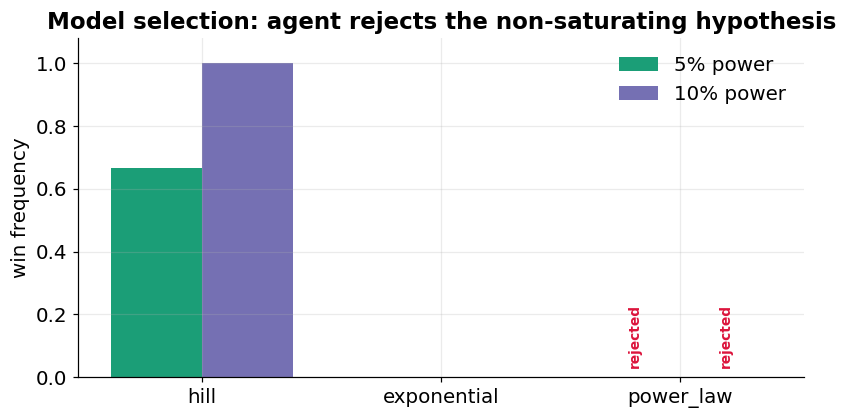

power 5%: selected='hill', power_law win-freq=0.00
power 10%: selected='hill', power_law win-freq=0.00


In [6]:
fig, ax = plt.subplots(figsize=(7.6, 4))
W = 0.38
for j, pw in enumerate((5, 10)):
    m = joblib.load(B[pw]["models"][-1])
    names = m["candidate_names_by_task"]["auc"]
    rec = np.asarray(m["task_state"]["auc"]["record"])
    wf = [float(rec[i, 1]) for i in range(len(names))]
    x = np.arange(len(names)) + (j - 0.5) * W
    bars = ax.bar(x, wf, W, color=COL[pw], label=f"{pw}% power")
    for xi, v, nm in zip(x, wf, names):
        if nm == "power_law":
            ax.text(
                xi,
                0.04,
                "rejected",
                ha="center",
                rotation=90,
                color="crimson",
                fontweight="bold",
                fontsize=9,
            )
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names)
ax.set_ylabel("win frequency")
ax.set_ylim(0, 1.08)
ax.set_title("Model selection: agent rejects the non-saturating hypothesis")
ax.legend()
plt.tight_layout()
save(fig, "F4_hypothesis_test")
plt.show()
for pw in (5, 10):
    m = joblib.load(B[pw]["models"][-1])
    sel = m["task_state"]["auc"]["selected_hypothesis"]
    print(
        f"power {pw}%: selected={sel!r}, power_law win-freq="
        f"{float(np.asarray(m['task_state']['auc']['record'])[2,1]):.2f}"
    )

**Reading E.** `power_law` wins **0.00** at both powers; `hill` is
selected. The agent *discovers* that peak ERK amplitude saturates — it doesn't
assume it. (Hill vs exponential is degenerate at these n; the meaningful
saturating-vs-not test is decisive.)

## F — Things I am critical about

The run is good; here is where I would not let the pitch overreach.

F-CRIT 1  RECIPROCITY:
   EC50 5% = 75 ms (CI 57-102); 10% = 85 ms (CI 69-103) -- CIs OVERLAP.
   A 2x power change barely moved the duration-EC50 => duration and power are NOT simply reciprocal here; the system is near power-saturation in 5-10%. (Do not claim a clean Bunsen-Roscoe light-budget axis.)

F-CRIT 2  REPRODUCIBILITY: EC50 at 10% power was 32 ms in v5 vs 85 ms in v6 (~2.6x).
   v6 is the trustworthy number (clean data), but a single-plate EC50 is plate/condition dependent -> biological replicates needed for a hard number.

F-CRIT 3  COOPERATIVITY: Hill n = 1.49 (5%) vs 1.99 (10%) -- n is not stable; don't over-interpret it.
saved pitch_figures_v6\F6_expression_confound.png


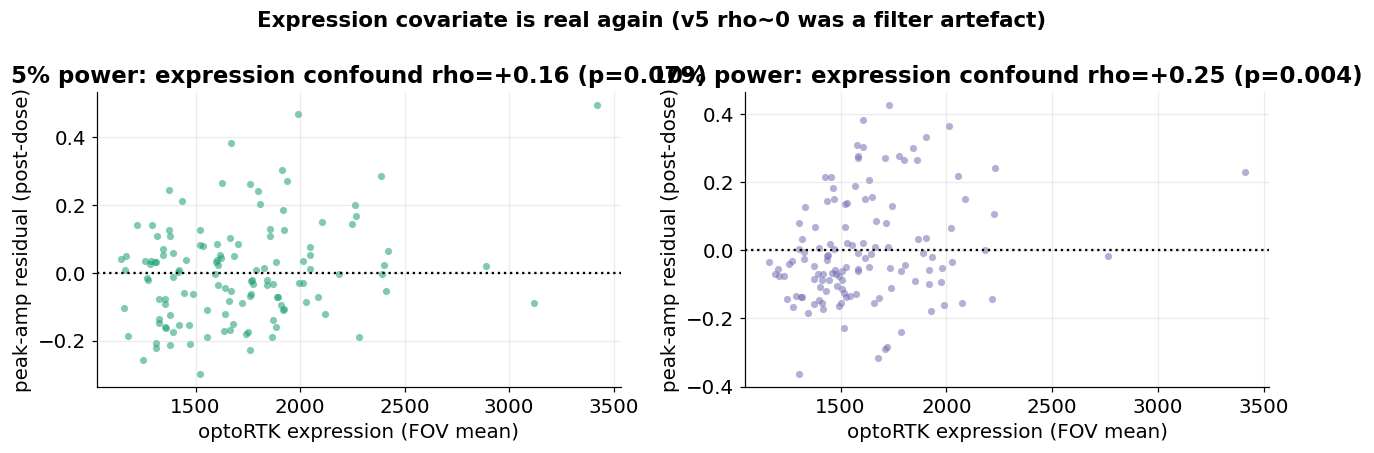


F-CRIT 4  CONFOUND: expression explains real residual variance again -> modelling it is justified, but it also inflates the covariate-marginalised band; per-cell expression would tighten it.

F-CRIT 5  CONTROL: 0 ms control had 31/31 frames at analysis time (still acquiring) -- the negative-control anchor is pending.


In [7]:
# F1: power 5 vs 10 -- is the dose-response reciprocal? (overlapping EC50 CIs)
e5 = np.percentile(fit[5]["ec"], [2.5, 50, 97.5])
e10 = np.percentile(fit[10]["ec"], [2.5, 50, 97.5])
print("F-CRIT 1  RECIPROCITY:")
print(
    f"   EC50 5% = {e5[1]:.0f} ms (CI {e5[0]:.0f}-{e5[2]:.0f}); "
    f"10% = {e10[1]:.0f} ms (CI {e10[0]:.0f}-{e10[2]:.0f}) -- CIs OVERLAP."
)
print(
    "   A 2x power change barely moved the duration-EC50 => duration and power"
    " are NOT simply reciprocal here; the system is near power-saturation in"
    " 5-10%. (Do not claim a clean Bunsen-Roscoe light-budget axis.)"
)

# F2: reproducibility v5-p10 vs v6-p10
df5v = pd.read_parquet(os.path.join(V5_RUN, "bo_results_checkpoint.parquet"))
pv, _ = curve_fit(
    hill,
    df5v.pulse_duration.values,
    df5v.mean_peak_amp.values,
    p0=P0,
    bounds=BND,
    maxfev=40000,
)
print(
    f"\nF-CRIT 2  REPRODUCIBILITY: EC50 at 10% power was {pv[1]:.0f} ms in v5 "
    f"vs {fit[10]['popt'][1]:.0f} ms in v6 (~{fit[10]['popt'][1]/pv[1]:.1f}x)."
)
print(
    "   v6 is the trustworthy number (clean data), but a single-plate EC50 is"
    " plate/condition dependent -> biological replicates needed for a hard number."
)

# F3: Hill n not stable across powers
print(
    f"\nF-CRIT 3  COOPERATIVITY: Hill n = {fit[5]['popt'][2]:.2f} (5%) vs "
    f"{fit[10]['popt'][2]:.2f} (10%) -- n is not stable; don't over-interpret it."
)

# F4: expression confound returned (good for covariate; inflates marginal band)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for j, pw in enumerate((5, 10)):
    df = B[pw]["df"]
    ld = np.log10(df.pulse_duration.values)
    sl, ic, r, p, se = stats.linregress(ld, df.mean_peak_amp.values)
    res = df.mean_peak_amp.values - (sl * ld + ic)
    rho, pv2 = stats.spearmanr(df.optortk_expression.values, res)
    ax[j].scatter(df.optortk_expression.values, res, s=22, c=COL[pw], alpha=0.55, lw=0)
    ax[j].axhline(0, ls=":", c="k")
    ax[j].set_xlabel("optoRTK expression (FOV mean)")
    ax[j].set_ylabel("peak-amp residual (post-dose)")
    ax[j].set_title(f"{pw}% power: expression confound rho={rho:+.2f} (p={pv2:.3f})")
fig.suptitle(
    "Expression covariate is real again (v5 rho~0 was a filter artefact)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
save(fig, "F6_expression_confound")
plt.show()
print(
    "\nF-CRIT 4  CONFOUND: expression explains real residual variance again"
    " -> modelling it is justified, but it also inflates the covariate-"
    "marginalised band; per-cell expression would tighten it."
)
print(
    f"\nF-CRIT 5  CONTROL: 0 ms control had {ctrl_frames}/31 frames at analysis"
    " time (still acquiring) -- the negative-control anchor is pending."
)

**Reading F.**

- **F1 — not reciprocal.** EC50 at 5% and 10% overlap (75 vs 85 ms). A 2×
  power change barely moves the duration-EC50, so the system is near
  power-saturation in this range; don't sell a clean duration×power
  light-budget axis. (Interesting in its own right: duration is the dominant
  lever here.)
- **F2 — reproducibility.** "Same" 10% power gave EC50 32 ms in v5 vs 85 ms in
  v6. v6 is trustworthy (clean data), but a single-plate EC50 is
  condition-dependent — quote it with that caveat and run biological
  replicates before a hard number.
- **F3 — Hill n is not stable** (1.5 vs 2.0); report the curve/EC50, not a
  cooperativity claim.
- **F4 — the expression confound is back** (ρ = +0.25 at 10%) — good (it
  validates modelling expression) but it inflates the covariate-marginalised
  band; per-cell expression would tighten it.
- **F5 — the 0 ms control was still acquiring** at analysis time; re-run this
  notebook once it finishes to populate the negative-control anchor.

## G — The slide-ready pitch (claim / don't claim)

### What v6 demonstrates — the method works
1. **An autonomous agent measured a calibrated ERK dose-response** — EC50 with
   a credible interval, at two powers, in 7 phases / 126 FOVs each — and
   **discovered the response saturates** by rejecting the non-saturating model
   from data.
2. **It samples where the biology is.** A log dose axis + uncertainty-driven
   acquisition concentrated FOVs on the steep knee and the plateau.
3. **It is self-correcting across iterations.** v3 (falsification) → v5 (clean
   readout, but data loss) → v6 (data recovered, 100% survival, ~47 cells/FOV)
   — each critique fed a concrete, effective fix.

### What I would NOT claim
- ❌ A single universal EC50 — it is plate- and power-conditioned (F1, F2).
- ❌ Reciprocity / a clean light-budget axis (F1).
- ❌ Meaningful Hill cooperativity (F3).
- ❌ "Expression doesn't matter" — it does (F4).

## H — Caveats & next steps

1. **Biological replicates** (≥2 plates) — turn the single-plate EC50 into one
   with across-plate error bars.
2. **Finish + integrate the 0 ms control** (F5) and add it to the hero figure.
3. **Per-cell expression** as the covariate (not the FOV mean) to tighten the
   band (F4).
4. **If a light-budget axis is wanted**, probe a wider power range than 5–10%
   (they are near power-saturation); or fix power and own duration as the lever.
5. **Lower-dose anchoring**: with EC50 ~80 ms, a couple more candidates in
   30–150 ms would sharpen the rising limb further.

*Figures for the deck are saved in* `pitch_figures_v6/` *(F1 hero, F2 active
learning, F3 EC50 CI, F4 hypothesis test, F5 data recovery, F6 expression).*